In [1]:
# Import libraries. You may or may not use all of these.
!pip install -q git+https://github.com/tensorflow/docs
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
  # %tensorflow_version only exists in Colab.
  %tensorflow_version 2.x
except Exception:
  pass
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers

import tensorflow_docs as tfdocs
import tensorflow_docs.plots
import tensorflow_docs.modeling

  Preparing metadata (setup.py) ... done
Colab only includes TensorFlow 2.x; %tensorflow_version has no effect.


In [2]:
# Import data
!wget https://cdn.freecodecamp.org/project-data/health-costs/insurance.csv
dataset = pd.read_csv('insurance.csv')
dataset.tail()

--2024-01-05 14:26:51--  https://cdn.freecodecamp.org/project-data/health-costs/insurance.csv
Resolving cdn.freecodecamp.org (cdn.freecodecamp.org)... 172.67.70.149, 104.26.3.33, 104.26.2.33, ...
Connecting to cdn.freecodecamp.org (cdn.freecodecamp.org)|172.67.70.149|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 50264 (49K) [text/csv]
Saving to: ‘insurance.csv’

insurance.csv       100%[===================>]  49.09K  --.-KB/s    in 0s      

2024-01-05 14:26:51 (138 MB/s) - ‘insurance.csv’ saved [50264/50264]



,age,sex,bmi,children,smoker,region,expenses
1333,50,male,31.0,3,no,northwest,10600.55
1334,18,female,31.9,0,no,northeast,2205.98
1335,18,female,36.9,0,no,southeast,1629.83
1336,21,female,25.8,0,no,southwest,2007.95
1337,61,female,29.1,0,yes,northwest,29141.36


In [3]:
# inspect the data
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   expenses  1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [4]:
dataset['sex'].unique()

array(['female', 'male'], dtype=object)

In [5]:
dataset['smoker'].unique()

array(['yes', 'no'], dtype=object)

In [6]:
dataset['region'].unique()

array(['southwest', 'southeast', 'northwest', 'northeast'], dtype=object)

In [7]:
sex_map = {
    'male' : 0,
    'female' : 1
}
smoker_map = {
    'yes' : 0,
    'no' : 1
}
region_map = {
    'southwest' : 0,
    'southeast' : 1,
    'northwest' : 2,
    'northeast' : 3
}

dataset['sex'] = dataset['sex'].map(sex_map)
dataset['smoker'] = dataset['smoker'].map(smoker_map)
dataset['region'] = dataset['region'].map(region_map)

In [8]:
dataset.tail()

,age,sex,bmi,children,smoker,region,expenses
1333,50,0,31.0,3,1,2,10600.55
1334,18,1,31.9,0,1,3,2205.98
1335,18,1,36.9,0,1,1,1629.83
1336,21,1,25.8,0,1,0,2007.95
1337,61,1,29.1,0,0,2,29141.36


In [9]:
train_dataset = dataset.sample(frac=0.8, random_state=123)
test_dataset = dataset.drop(train_dataset.index)

train_features = train_dataset.copy()
test_features = test_dataset.copy()

train_labels = train_features.pop('expenses')
test_labels = test_features.pop('expenses')

In [32]:
model = tf.keras.Sequential([
    keras.layers.Dense(64, activation="relu"),
    keras.layers.Dense(64, activation ="relu"),
    keras.layers.Dense(1, activation="relu")
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss='mean_squared_error',
    metrics=['mae', 'mse'])

history = model.fit(
    train_features,
    train_labels,
    epochs=300,
    verbose=1)

Epoch 1/300
34/34 [==============================] - 1s 2ms/step - loss: 315316096.0000 - mae: 13110.5049 - mse: 315316096.0000
Epoch 2/300
34/34 [==============================] - 0s 2ms/step - loss: 312129504.0000 - mae: 12997.2715 - mse: 312129504.0000
Epoch 3/300
34/34 [==============================] - 0s 2ms/step - loss: 304618112.0000 - mae: 12721.4355 - mse: 304618112.0000
Epoch 4/300
34/34 [==============================] - 0s 2ms/step - loss: 289324640.0000 - mae: 12139.5254 - mse: 289324640.0000
Epoch 5/300
34/34 [==============================] - 0s 2ms/step - loss: 263754928.0000 - mae: 11133.8604 - mse: 263754928.0000
Epoch 6/300
34/34 [==============================] - 0s 2ms/step - loss: 228900032.0000 - mae: 9721.4307 - mse: 228900032.0000
Epoch 7/300
34/34 [==============================] - 0s 2ms/step - loss: 190757600.0000 - mae: 8286.9238 - mse: 190757600.0000
Epoch 8/300
34/34 [==============================] - 0s 2ms/step - loss: 158102896.0000 - mae: 7466.2397 -

9/9 - 0s - loss: 30420204.0000 - mae: 3481.1660 - mse: 30420204.0000 - 151ms/epoch - 17ms/step
Testing set Mean Abs Error: 3481.17 expenses
You passed the challenge. Great job!
9/9 [==============================] - 0s 2ms/step


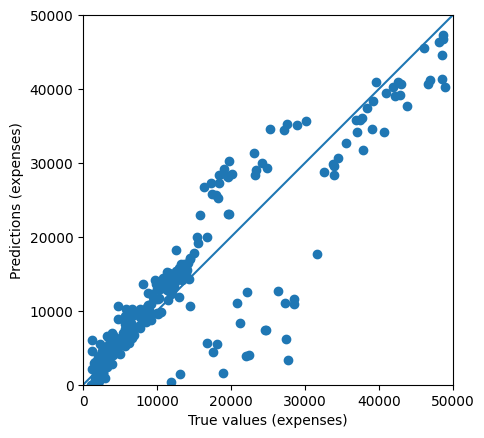

In [33]:
# RUN THIS CELL TO TEST YOUR MODEL. DO NOT MODIFY CONTENTS.
# Test model by checking how well the model generalizes using the test set.
loss, mae, mse = model.evaluate(test_features, test_labels, verbose=2)

print("Testing set Mean Abs Error: {:5.2f} expenses".format(mae))

if mae < 3500:
  print("You passed the challenge. Great job!")
else:
  print("The Mean Abs Error must be less than 3500. Keep trying.")

# Plot predictions.
test_predictions = model.predict(test_features).flatten()

a = plt.axes(aspect='equal')
plt.scatter(test_labels, test_predictions)
plt.xlabel('True values (expenses)')
plt.ylabel('Predictions (expenses)')
lims = [0, 50000]
plt.xlim(lims)
plt.ylim(lims)
_ = plt.plot(lims,lims)
